In [1]:
from sklearn.datasets import make_regression
import numpy as np

In [2]:
x,y = make_regression(n_samples=4, n_features=1, n_informative=1, n_targets=1, noise=80, random_state=13)

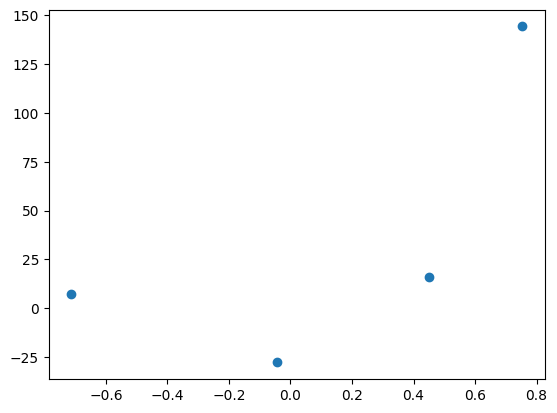

In [3]:
import matplotlib.pyplot as plt
plt.scatter(x,y)
plt.show()

In [4]:
## Lets apply OLS
from sklearn.linear_model import LinearRegression

In [5]:
lr = LinearRegression()

In [6]:
lr.fit(x,y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [7]:
lr.coef_

array([78.35063668])

In [8]:
lr.intercept_

np.float64(26.15963284313262)

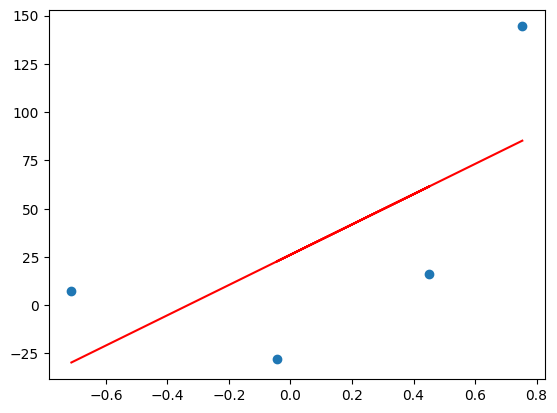

In [9]:
plt.scatter(x,y)
plt.plot(x,lr.predict(x),c = 'r')

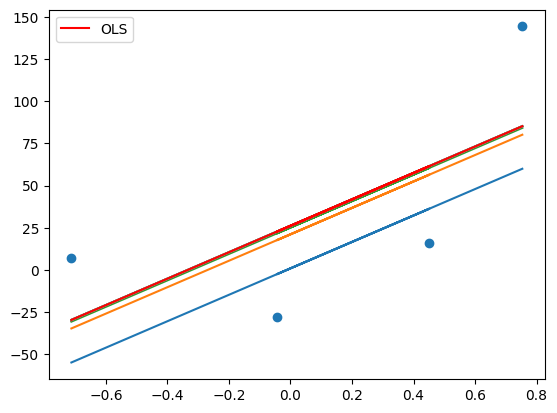

In [10]:
# lets assuming value of 'm' and 'b' to apply gredient descent

m = 78.35
b = -100
epoach = 10
l_rate = 0.1

for i in range(epoach):
    loss_slope = -2 * np.sum(y - m * x.ravel() - b)
    b = b - (l_rate * loss_slope)
    
    y_pred  = (m * x )+ b

    plt.plot(x, y_pred)
    
plt.scatter(x,y)
plt.plot(x,lr.predict(x), c='r', label='OLS')
plt.legend()
plt.show()

# Own GD regressor Class

In [1]:
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import cross_val_score

In [2]:
x,y = make_regression(n_samples=100, n_features=1, n_informative=1, n_targets=1, noise=20)

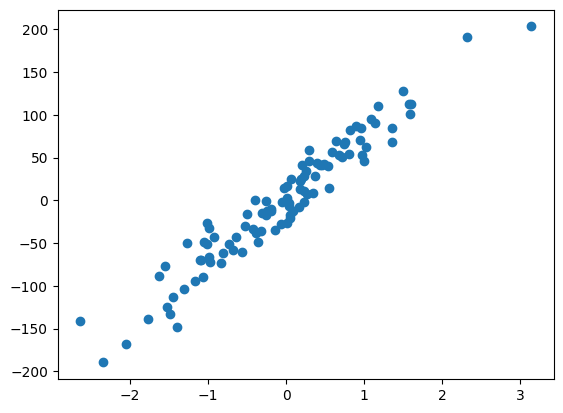

In [4]:
plt.scatter(x,y)

In [39]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2,random_state=2)

In [40]:
from sklearn.linear_model import LinearRegression
lrm = LinearRegression()

In [41]:
lrm.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [42]:
lrm.coef_

array([71.74843626])

In [43]:
lrm.intercept_

np.float64(2.993050423650474)

In [48]:
y_pred = lrm.predict(x_test)
from sklearn.metrics import r2_score
r2_score(y_test, y_pred)

0.8895245215293297

In [49]:
class GDRegressor:

    def __init__ (self,learning_rate, epochs):
        self.m = 100
        self.b = -120
        self.lrm = learning_rate
        self.epochs = epochs

    def fit(self,x,y):
        # clculating the b using GD
        for i in range(self.epochs):
            loss_slope_b = -2* np.sum(y -( self.m * x.ravel()) - self.b)
            loss_slope_m = -2 * np.sum((y - ((self.m * x.ravel())- self.b))*x.ravel())
            self.b = self.b - (self.lrm*loss_slope_b)
            self.m = self.m - (self.lrm*loss_slope_m)

        print(self.m,self.b)

    def predict(self,x):
        return self.m*x + self.b

In [50]:
gd = GDRegressor(0.001, 40)

In [52]:
gd.fit(x_train,y_train)

71.82789275940249 2.9913612330493167


In [53]:
y_pred = gd.predict(x_test)
from sklearn.metrics import r2_score
r2_score(y_test,y_pred)

0.8894303363729309